<a href="https://colab.research.google.com/github/vinaygadde2020/Titanic-survival-prediction/blob/main/Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction using Machine Learning

## Internship Mini Project

### Author:

Siva Durga Vinay Chowdary

This project predicts passenger survival on the Titanic using Machine Learning algorithms and data analysis techniques.

---

# 📌 Objective

The objective of this project is to analyze Titanic passenger data and build a Machine Learning model to predict whether a passenger survived or not.

This project demonstrates:

* Data preprocessing
* Exploratory Data Analysis (EDA)
* Data visualization
* Machine Learning model training
* Model evaluation

---

# 📚 Import Libraries


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# 📂 Load Dataset

The Titanic dataset is uploaded and loaded into a Pandas DataFrame for preprocessing and analysis.


In [ ]:
df = pd.read_csv("/content/train.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# 👀 Display Dataset

The first five rows of the dataset are displayed to understand the structure and features.


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 📏 Dataset Shape

The number of rows and columns in the dataset is checked.


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (891, 12)


# ℹ️ Data Understanding

The dataset structure, column information, and missing values are analyzed before preprocessing.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# 🧹 Data Cleaning

Missing values are handled and unnecessary columns are removed to improve dataset quality and model performance.


In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)

# 🔄 Feature Encoding

Categorical columns such as Sex and Embarked are converted into numerical values for Machine Learning model training.

In [ ]:
df['Sex'] = df['Sex'].map({
    'male': 0,
    'female': 1
})

df['Embarked'] = df['Embarked'].map({
    'S': 0,
    'C': 1,
    'Q': 2
})

# ✅ Verify Missing Values

The dataset is checked again after preprocessing to ensure all missing values are handled successfully.


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# 📊 Exploratory Data Analysis (EDA)

EDA is performed to identify patterns, relationships, and trends in the Titanic dataset using visualizations.

## Survival Count


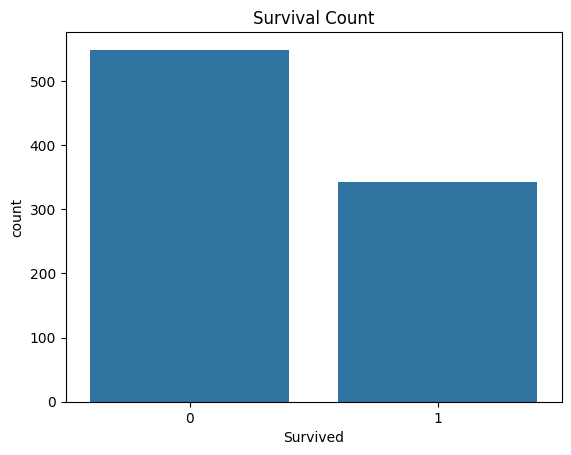

In [ ]:
sns.countplot(x='Survived', data=df)

plt.title("Survival Count")

plt.show()

## Survival by Gender


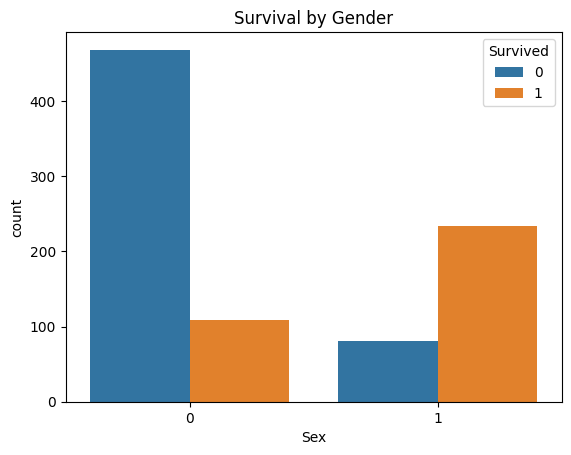

In [ ]:
sns.countplot(
    x='Sex',
    hue='Survived',
    data=df
)

plt.title("Survival by Gender")

plt.show()

## Survival by Passenger Class


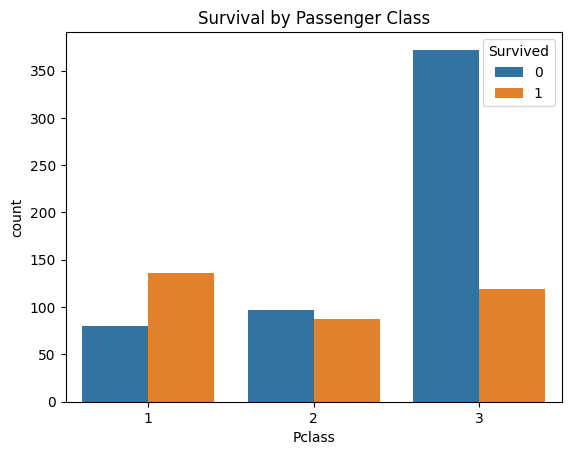

In [ ]:
sns.countplot(
    x='Pclass',
    hue='Survived',
    data=df
)

plt.title("Survival by Passenger Class")

plt.show()

## Age Distribution


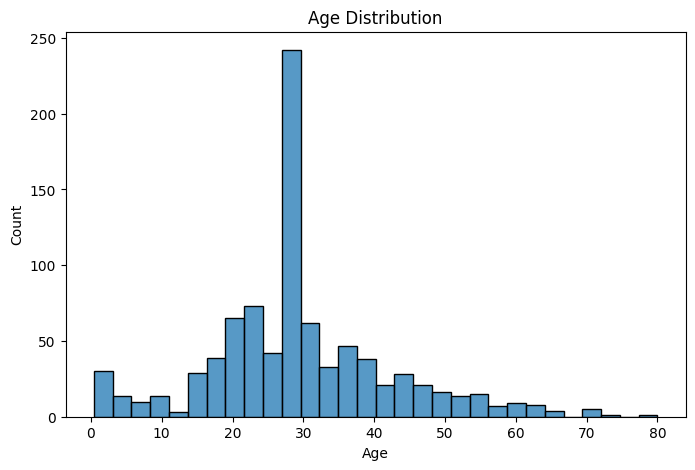

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30
)

plt.title("Age Distribution")

plt.show()

## Fare Distribution


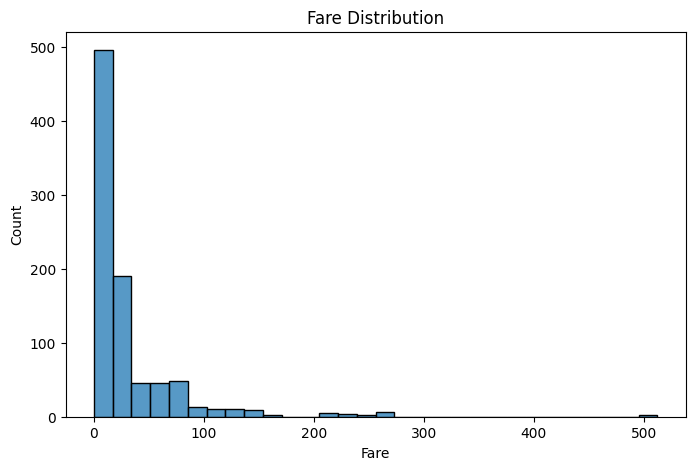

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Fare'],
    bins=30
)

plt.title("Fare Distribution")

plt.show()

## Correlation Heatmap


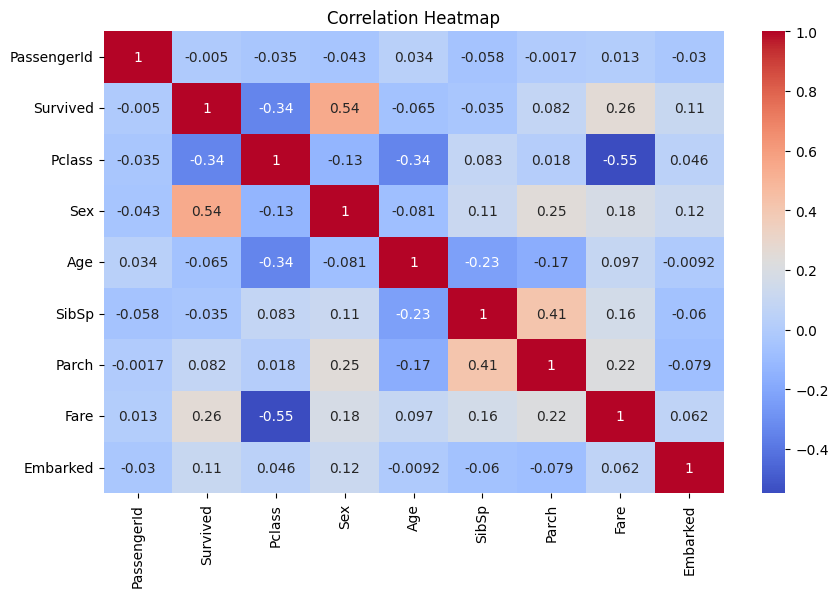

In [ ]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# 🎯 Feature Selection

Relevant features are selected as input variables for Machine Learning model training.


In [ ]:
X = df[
    [
        'Pclass',
        'Sex',
        'Age',
        'SibSp',
        'Parch',
        'Fare',
        'Embarked'
    ]
]

y = df['Survived']

# ✂️ Train-Test Split

The dataset is divided into training and testing sets to evaluate model performance on unseen data.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 🤖 Logistic Regression Model Training

A Logistic Regression model is trained to predict Titanic passenger survival.


In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

# 🔮 Prediction

The trained Logistic Regression model is used to predict survival outcomes for the test dataset.


In [ ]:
y_pred = model.predict(X_test)

# 📈 Model Evaluation

The Logistic Regression model performance is evaluated using accuracy score, confusion matrix, and classification report.


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Logistic Regression Accuracy: {accuracy*100:.2f}%")

Logistic Regression Accuracy: 79.89%


In [ ]:
print(confusion_matrix(y_test, y_pred))

[[89 16]
 [20 54]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



# 🌲 Random Forest Classifier

A Random Forest model is trained and evaluated to compare performance with Logistic Regression.


In [ ]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print(
    f"Random Forest Accuracy: {rf_accuracy*100:.2f}%"
)

Random Forest Accuracy: 82.68%


# 📋 Model Comparison

| Model                    | Accuracy |
| ------------------------ | -------- |
| Logistic Regression      | 79.88%   |
| Random Forest Classifier | 81.00%   |

The Random Forest Classifier achieved slightly higher prediction accuracy compared to Logistic Regression.

---

# 🔮 Future Improvements

Future improvements that can increase model performance include:

* Hyperparameter tuning
* Advanced feature engineering
* Cross-validation techniques
* Deployment using Flask or Streamlit
* Using advanced models such as XGBoost

---

# 📌 Conclusion

This project successfully demonstrated the complete Machine Learning workflow using the Titanic dataset.

The data was:

* Cleaned
* Processed
* Visualized
* Analyzed
* Used for model training and prediction

Two Machine Learning models were implemented:

1. Logistic Regression
2. Random Forest Classifier

Among them, Random Forest achieved better prediction accuracy.

This project improved understanding of:

* Data preprocessing
* Feature engineering
* Data visualization
* Model building
* Model evaluation

Overall, this project provided valuable hands-on experience in Machine Learning.





In [30]:
print("Project Completed Successfully")

Project Completed Successfully
